# 03 - Modeling & Evaluation
**Goal:** Train multiple models, evaluate them properly, compare performance and save the best model for deployment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
print("Libraries Loaded")

Libraries Loaded


#### Loading Preprocessed Data

In [2]:
df = pd.read_csv('../data/telco_preprocessed.csv')

X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (7032, 30)
Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


#### Train Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        #
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (5625, 30)
Test size: (1407, 30)


#### Handling Class Imbalance

In [4]:
# Our churn rate is ~26% — we tell models to pay more attention to minority class
# scale_pos_weight for XGBoost, class_weight for others

churn_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {round(churn_ratio, 2)}")
print("We'll pass this to XGBoost as scale_pos_weight")

Class imbalance ratio: 2.76
We'll pass this to XGBoost as scale_pos_weight


#### Training All 3 Models

In [5]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("Logistic Regression trained")

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained")

# XGBoost
xgb = XGBClassifier(
    scale_pos_weight=churn_ratio,
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
print("XGBoost trained")

Logistic Regression trained
Random Forest trained
XGBoost trained


#### Evaluating All Models

In [6]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb 
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        'Model': name,
        'Accuracy': round(report['accuracy'], 3),
        'Precision (Churn)': round(report['1']['precision'], 3),
        'Recall (Churn)': round(report['1']['recall'], 3),
        'F1 (Churn)': round(report['1']['f1-score'], 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 3)
    })
    
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
0,Logistic Regression,0.726,0.490,0.794,0.606,0.835
1,Random Forest,0.789,0.631,0.495,0.555,0.821
2,XGBoost,0.753,0.527,0.684,0.595,0.815


#### Plotting ROC Curves for all models

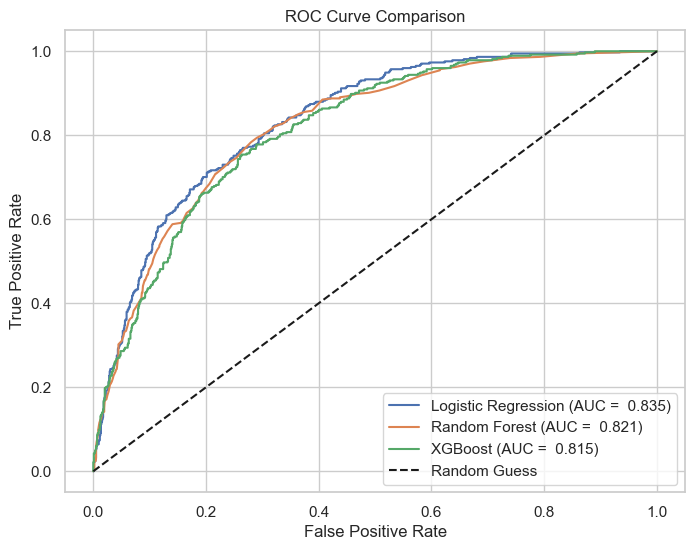

In [7]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc: .3f})")
    
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('../data/roc_curves.png', bbox_inches='tight')
plt.show()

#### Confusion Matrix for best model

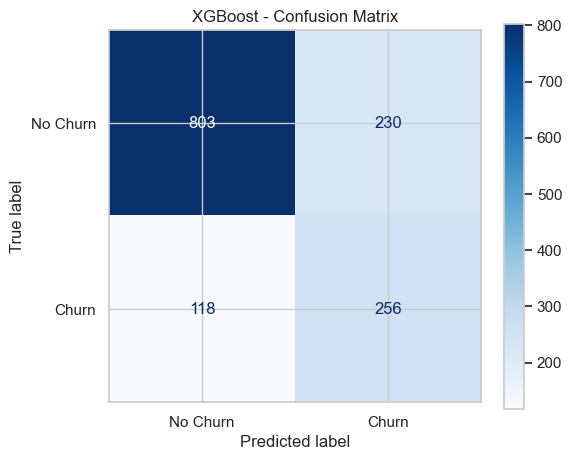

In [8]:
# We'll use XGBoost for our best model
y_pred_xgb = xgb.predict(X_test)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues',
    ax=ax
)

plt.title('XGBoost - Confusion Matrix')
plt.savefig('../data/confusion_matrix.png', bbox_inches='tight')
plt.show()

#### Feature Importance

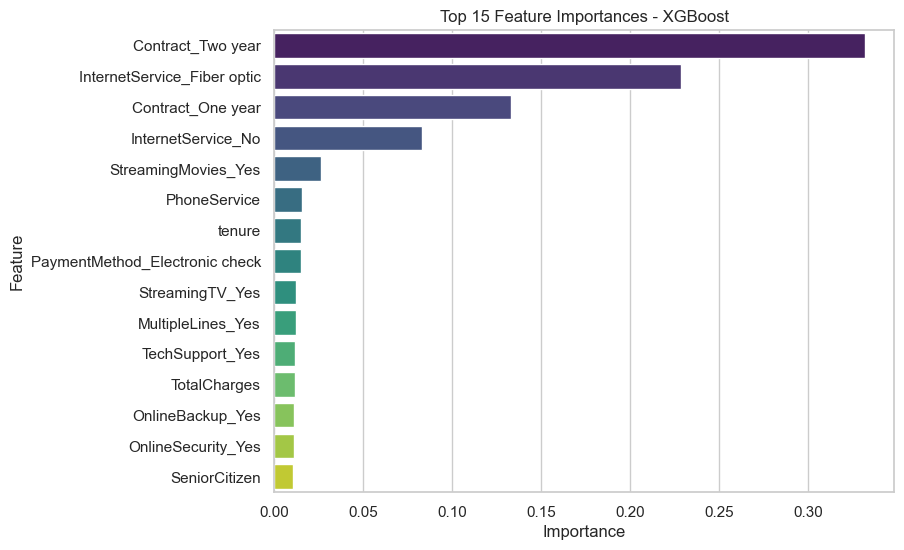

In [9]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature')
plt.title('Top 15 Feature Importances - XGBoost')
plt.savefig('../data/feature_importance.png', bbox_inches='tight')
plt.show()

#### Business Impact Calculator

In [10]:
# Average monthly revenue per customer
raw_df = pd.read_csv('../data/telco_churn.csv')
avg_monthly_revenue = pd.to_numeric(raw_df['MonthlyCharges'], errors='coerce').mean()

# Get predicted churn probability
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Flag high-risk customers (probability > 0.5)
high_risk = (y_prob_lr > 0.5).sum()

# Estimated revenue at risk
revenue_at_risk = high_risk * avg_monthly_revenue
revenue_at_risk_annual = revenue_at_risk * 12

# If we retain 30% of flagged customers
retention_rate = 0.30
revenue_saved = revenue_at_risk_annual * 0.30

print("=" * 45)
print("       BUSINESS IMPACT SUMMARY")
print("=" * 45)
print(f"High-risk customers identified : {high_risk}")
print(f"Avg monthly charge             : ${avg_monthly_revenue:.2f}")
print(f"Annual revenue at risk         : ${revenue_at_risk_annual:,.2f}")
print(f"Estimated revenue saveable     : ${revenue_saved:,.2f}")
print("  (assuming 30% retention rate)")
print("=" * 45)

       BUSINESS IMPACT SUMMARY
High-risk customers identified : 606
Avg monthly charge             : $64.76
Annual revenue at risk         : $470,947.03
Estimated revenue saveable     : $141,284.11
  (assuming 30% retention rate)


#### Saving the best model

In [11]:
# Logistic Regression wins based on Recall and ROC-AUC
best_model = lr

with open('../src/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
print("Best Model: Logistic Regression ")
print("Model Saved")

Best Model: Logistic Regression 
Model Saved


## Final Summary Markdown

### Modeling Summary

| Model | Accuracy | Recall (Churn) | ROC-AUC |
|---|---|---|---|
| Logistic Regression | ~0.726 | **~0.794** | **~0.835** |
| Random Forest | ~0.789 | ~0.495 | ~0.821 |
| XGBoost | ~0.753 | ~0.684 | ~0.815 |

**Best Model: Logistic Regression**
- Highest ROC-AUC (0.835) and Recall (0.794) on churn class
- Chosen over complex models because catching churners matters more than raw accuracy
- A simpler, interpretable model that outperformed ensemble methods on this dataset